# 04. Mitigación de sesgo mediante Equalized Odds

Este notebook aplica un postprocesamiento de *Equalized Odds* a la regresión logística. El objetivo es reducir las diferencias de verdaderos y falsos positivos entre grupos de sexo y cuantificar el coste de la mitigación sobre el rendimiento global.

**Entrada:** `data/processed/df_model.pkl`.

**Resultado:** comparación de métricas por grupo antes y después del ajuste.


## 1. Dependencias


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import MetricFrame, true_positive_rate, false_positive_rate, selection_rate


## 2. Carga y muestreo de datos


In [ ]:
df_model = pd.read_pickle("data/processed/df_model.pkl")


In [ ]:
df_sample = df_model.groupby('target', group_keys=False).sample(frac=0.80, random_state=42)


## 3. Preparación de variables


In [ ]:
# Features y target del modelo base (sin variables sensibles)
X2 = df_sample.drop(columns=['target'], errors='ignore')
y2 = df_sample['target']

# One-hot encoding
X2 = pd.get_dummies(X2, drop_first=True)

# Eliminar variables sensibles
sensibles = ['sexo', 'raza', 'etnia']
X2 = X2.loc[:, ~X2.columns.str.contains('|'.join(sensibles), case=False)]

print("Columnas sensibles restantes:")
print([col for col in X2.columns if any(s in col.lower() for s in sensibles)])


Columnas sensibles restantes:
[]


In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)


## 4. Modelo logístico de referencia


In [ ]:
logit_model_2 = LogisticRegression(
    max_iter=500,
    solver='saga',
    n_jobs=-1,
    tol=1e-2
)

logit_model_2.fit(X2_train, y2_train)


c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.01
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
y_pred_2 = logit_model_2.predict(X2_test)
y_prob_2 = logit_model_2.predict_proba(X2_test)[:, 1]

print("Accuracy:", accuracy_score(y2_test, y_pred_2))
print("AUC:", roc_auc_score(y2_test, y_prob_2))
print("Matriz de confusión:")
print(confusion_matrix(y2_test, y_pred_2))


Accuracy: 0.6948658375472644
AUC: 0.7435225059001217
Matriz de confusión:
[[ 26250 132370]
 [  1590 278810]]


## 5. Métricas por grupo


In [ ]:
A_test_sexo = df_sample.loc[X2_test.index, 'sexo']
A_train_sexo = df_sample.loc[X2_train.index, 'sexo']


In [ ]:
# Atributo sensible para auditoría y post-procesamiento
A_train_sexo = df_sample.loc[X2_train.index, 'sexo']
A_test_sexo = df_sample.loc[X2_test.index, 'sexo']

print(A_train_sexo.value_counts(dropna=False))
print(A_test_sexo.value_counts(dropna=False))


sexo
hombre    1051529
mujer      704549
Name: count, dtype: int64
sexo
hombre    262986
mujer     176034
Name: count, dtype: int64


In [ ]:
from fairlearn.metrics import MetricFrame, true_positive_rate, false_positive_rate, selection_rate
from sklearn.metrics import accuracy_score

metricas_base_sexo = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "TPR": true_positive_rate,
        "FPR": false_positive_rate,
        "selection_rate": selection_rate
    },
    y_true=y2_test,
    y_pred=y_pred_2,
    sensitive_features=A_test_sexo
)

print("Métricas por grupo - Modelo base")
display(metricas_base_sexo.by_group)

print("\nDiferencias entre grupos - Modelo base")
print(metricas_base_sexo.difference())


Métricas por grupo - Modelo base


,accuracy,TPR,FPR,selection_rate
sexo,,,,
hombre,0.696756,0.995280,0.852133,0.944853
mujer,0.692042,0.992858,0.809764,0.924236



Diferencias entre grupos - Modelo base
accuracy          0.004713
TPR               0.002422
FPR               0.042369
selection_rate    0.020616
dtype: float64


## 6. Postprocesamiento con Equalized Odds


In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer

eo_postprocessor = ThresholdOptimizer(
    estimator=logit_model_2,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True
)

eo_postprocessor.fit(
    X2_train,
    y2_train,
    sensitive_features=A_train_sexo
)


,estimator,"LogisticRegre...ga', tol=0.01)"
,constraints,'equalized_odds'
,objective,'accuracy_score'
,grid_size,1000
,flip,False
,prefit,True
,predict_method,'predict_proba'
,tol,None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0


In [ ]:
y_pred_eo_sexo = eo_postprocessor.predict(
    X2_test,
    sensitive_features=A_test_sexo
)


## 7. Comparación de resultados


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

print("=== MODELO BASE ===")
print("Accuracy:", accuracy_score(y2_test, y_pred_2))
print("Matriz de confusión:")
print(confusion_matrix(y2_test, y_pred_2))

print("\n=== MODELO CON EQUALIZED ODDS ===")
print("Accuracy:", accuracy_score(y2_test, y_pred_eo_sexo))
print("Matriz de confusión:")
print(confusion_matrix(y2_test, y_pred_eo_sexo))


=== MODELO BASE ===
Accuracy: 0.6948658375472644
Matriz de confusión:
[[ 26250 132370]
 [  1590 278810]]

=== MODELO CON EQUALIZED ODDS ===
Accuracy: 0.730729807298073
Matriz de confusión:
[[ 61782  96838]
 [ 21377 259023]]


In [ ]:
metricas_eo_sexo = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "TPR": true_positive_rate,
        "FPR": false_positive_rate,
        "selection_rate": selection_rate
    },
    y_true=y2_test,
    y_pred=y_pred_eo_sexo,
    sensitive_features=A_test_sexo
)

print("Métricas por grupo - Equalized Odds")
display(metricas_eo_sexo.by_group)

print("\nDiferencias entre grupos - Equalized Odds")
print(metricas_eo_sexo.difference())


Métricas por grupo - Equalized Odds


,accuracy,TPR,FPR,selection_rate
sexo,,,,
hombre,0.735781,0.924135,0.610541,0.813663
mujer,0.723184,0.923186,0.610449,0.805975



Diferencias entre grupos - Equalized Odds
accuracy          0.012596
TPR               0.000949
FPR               0.000092
selection_rate    0.007688
dtype: float64


In [ ]:
comparacion_sexo = pd.concat(
    {
        "Base": metricas_base_sexo.by_group,
        "Equalized_Odds": metricas_eo_sexo.by_group
    },
    axis=1
)

comparacion_sexo


Base                                    Equalized_Odds            \
        accuracy       TPR       FPR selection_rate       accuracy       TPR   
sexo                                                                           
hombre  0.696756  0.995280  0.852133       0.944853       0.735781  0.924135   
mujer   0.692042  0.992858  0.809764       0.924236       0.723184  0.923186   

                                 
             FPR selection_rate  
sexo                             
hombre  0.610541       0.813663  
mujer   0.610449       0.805975

In [ ]:
gaps_sexo = pd.DataFrame({
    "Base": metricas_base_sexo.difference(),
    "Equalized_Odds": metricas_eo_sexo.difference()
})

gaps_sexo


,Base,Equalized_Odds
accuracy,0.004713,0.012596
TPR,0.002422,0.000949
FPR,0.042369,0.000092
selection_rate,0.020616,0.007688


## 8. Visualización de brechas


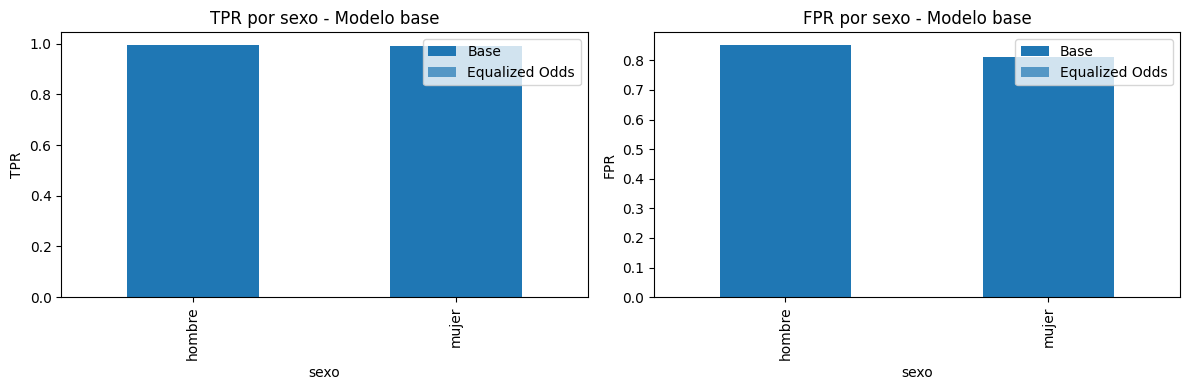

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metricas_base_sexo.by_group["TPR"].plot(kind="bar", ax=axes[0], title="TPR por sexo - Modelo base")
metricas_eo_sexo.by_group["TPR"].plot(kind="bar", ax=axes[0], alpha=0.7)
axes[0].legend(["Base", "Equalized Odds"])
axes[0].set_ylabel("TPR")

metricas_base_sexo.by_group["FPR"].plot(kind="bar", ax=axes[1], title="FPR por sexo - Modelo base")
metricas_eo_sexo.by_group["FPR"].plot(kind="bar", ax=axes[1], alpha=0.7)
axes[1].legend(["Base", "Equalized Odds"])
axes[1].set_ylabel("FPR")

plt.tight_layout()
plt.show()
